## **Вопросы викторины «Jeopardy»**

В данном проекте анализируется набор данных, содержащий вопросы викторины Jeopardy. Основная цель – выявить закономерности в вопросах, которые потенциально могут помочь успешнее отвечать на них при участии в игре. Особое внимание уделяется анализу вопросов с высоким вознаграждением за правильный ответ и поиску слов и тематик, характерных для этой категории.

In [1]:
#Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
from scipy.stats import chisquare
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('jeopardy.csv', na_values = ['None'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19999 entries, 0 to 19998
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Show Number  19999 non-null  int64 
 1    Air Date    19999 non-null  object
 2    Round       19999 non-null  object
 3    Category    19999 non-null  object
 4    Value       19663 non-null  object
 5    Question    19999 non-null  object
 6    Answer      19999 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.1+ MB


Ниже приведена таблица с описанием каждого столбца:

| Столбец | Описание |
| --- | --- |
| Show Number | Номер эпизода Jeopardy |
| Air Date | Дата выхода эпизода  |
| Round | Раунд |
| Category | Категория вопроса |
| Value | Вознаграждение за правильный ответ в $ |
| Question | Текст вопроса |
| Answer | Ответ |

Приведём названия столбцов к единому стилю (snake_case), а также сделаем название столбца `value` более информативным, добавив суффикс `_usd`:

In [3]:
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()
df.rename({'value':'value_usd'}, axis = 1, inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19999 entries, 0 to 19998
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   show_number  19999 non-null  int64 
 1   air_date     19999 non-null  object
 2   round        19999 non-null  object
 3   category     19999 non-null  object
 4   value_usd    19663 non-null  object
 5   question     19999 non-null  object
 6   answer       19999 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.1+ MB


Изучим первые и последние пять строк набора данных:

In [4]:
df

,show_number,air_date,round,category,value_usd,question,answer
0,4680,2004-12-31,Jeopardy!,HISTORY,$200,"For the last 8 years of his life, Galileo was ...",Copernicus
1,4680,2004-12-31,Jeopardy!,ESPN's TOP 10 ALL-TIME ATHLETES,$200,No. 2: 1912 Olympian; football star at Carlisl...,Jim Thorpe
2,4680,2004-12-31,Jeopardy!,EVERYBODY TALKS ABOUT IT...,$200,The city of Yuma in this state has a record av...,Arizona
3,4680,2004-12-31,Jeopardy!,THE COMPANY LINE,$200,"In 1963, live on ""The Art Linkletter Show"", th...",McDonald's
4,4680,2004-12-31,Jeopardy!,EPITAPHS & TRIBUTES,$200,"Signer of the Dec. of Indep., framer of the Co...",John Adams
...,...,...,...,...,...,...,...
19994,3582,2000-03-14,Jeopardy!,U.S. GEOGRAPHY,$200,"Of 8, 12 or 18, the number of U.S. states that...",18
19995,3582,2000-03-14,Jeopardy!,POP MUSIC PAIRINGS,$200,...& the New Power Generation,Prince
19996,3582,2000-03-14,Jeopardy!,HISTORIC PEOPLE,$200,In 1589 he was appointed professor of mathemat...,Galileo
19997,3582,2000-03-14,Jeopardy!,1998 QUOTATIONS,$200,"Before the grand jury she said, ""I'm really so...",Monica Lewinsky


Рассмотрим категориальные столбцы (`round` и `category`):

In [5]:
df[['round', 'category']].describe()

,round,category
count,19999,19999
unique,4,3581
top,Jeopardy!,TELEVISION
freq,9901,51


Как видно из результатов, телешоу включает четыре раунда. При этом раунд `Jeopardy!` встречается в `49 %` всех игр. Кроме того, в телешоу представлена `3581` уникальная категория вопросов.

---

Перед анализом данных необходимо выполнить их предварительную обработку (нормализацию), которая включает:
1. приведение текстовых данных (`question`, `answer`) к нижнему регистру и удаление знаков препинания;
2. преобразование столбца `air_date` в формат datetime;
3. преобразование столбца `value_usd` в числовой формат.

In [6]:
#Переводим столбцы с текстовыми данными в нижний регистр и убираем из них все знаки препинания
pattern = r"[.,!?:;'\"]"
df['clean_question'] = df['question'].str.lower().str.replace(pattern, "", regex = True)
df['clean_answer'] = df['answer'].str.lower().str.replace(pattern, "", regex = True)

df[['question', 'clean_question']].head()

,question,clean_question
0,"For the last 8 years of his life, Galileo was ...",for the last 8 years of his life galileo was u...
1,No. 2: 1912 Olympian; football star at Carlisl...,no 2 1912 olympian football star at carlisle i...
2,The city of Yuma in this state has a record av...,the city of yuma in this state has a record av...
3,"In 1963, live on ""The Art Linkletter Show"", th...",in 1963 live on the art linkletter show this c...
4,"Signer of the Dec. of Indep., framer of the Co...",signer of the dec of indep framer of the const...


In [7]:
# Преобразуем столбец с датой выхода эпизода в формат datetime
df['air_date'] = pd.to_datetime(df['air_date'])

# Отсортируем датафрейм по дате выхода эпизодов (от ранних к поздним)
df = df.sort_values('air_date', ignore_index=True)

# Добавим столбец с годом выхода эпизода для последующей группировки данных по годам
df['year'] = df['air_date'].dt.year

Поскольку `value_usd` является единственным столбцом, содержащим пропущенные значения, рассмотрим его более подробно:

In [8]:
df['value_usd'].unique()

array([nan, '$200', '$400', '$600', '$800', '$1,000', '$1000', '$500',
       '$100', '$300', '$1,900', '$1,400', '$1,200', '$3,100', '$1,800',
       '$1,500', '$2,500', '$900', '$2,000', '$3,600', '$700', '$1,100',
       '$3,000', '$1,300', '$2,600', '$4,700', '$1,600', '$2,400',
       '$1200', '$4,000', '$2,100', '$2,900', '$3,500', '$2,200', '$750',
       '$2,300', '$1,700', '$3,300', '$2000', '$1600', '$5,000', '$9,000',
       '$4,400', '$3,400', '$3,200', '$7,000', '$5,400', '$6,800',
       '$6,100', '$10,800', '$6,000', '$7,200', '$3,900', '$4,100',
       '$10,000', '$6,200', '$4,600', '$12,000', '$5,600', '$1,111',
       '$2,800', '$3,389', '$5,200', '$8,000', '$2,021', '$4,800',
       '$4,500', '$3,800', '$1,492', '$7,500', '$1,020', '$7,400',
       '$2,127', '$367', '$5,800', '$8,200'], dtype=object)

На текущий момент значения столбца `value_usd`, обозначающего размер денежного вознаграждения в случае правильного ответа, представлены в строковом формате. Большинство значений содержат символ `,`, используемый в качестве разделителя тысяч, а также символ `$`, обозначающий валюту. Перед преобразованием столбца в числовой тип данных (int) необходимо удалить эти символы:

In [9]:
#Заменяем $ и , пустым символом
df['value_usd'] = df['value_usd'].str.replace("[$,]", "", regex = True).str.strip()

Заменим пропущенные значения (`NaN`) на 0, после чего преобразуем столбец к целочисленному типу данных (int):

In [10]:
df['value_usd'] = df['value_usd'].fillna(0)
df['value_usd'] = df['value_usd'].astype(int)

---

В рамках стратегии анализа данных Jeopardy в первую очередь мы хотим понять, насколько вопрос может содержать подсказки к ответу. Для этого мы сравниваем слова из ответа со словами в вопросе и вычисляем долю совпадений. Чем выше эта доля, тем чаще ответ частично встречается в формулировке вопроса.

Напишем функцию `find_answer_in_question()`, которая реализует данный подход и вычисляет указанную метрику для каждой строки данных:

In [11]:
def find_answer_in_question(row):
    #Разбиваем ответ и вопрос на слова
    split_answer = row['clean_answer'].split() 
    split_question = row['clean_question'].split() 
    
    #Удаляем артикль 'the' из списка слов ответа
    if 'the' in split_answer: 
        split_answer.remove('the')
        
    #Если в ответе нет слов, то возвращаем 0    
    if len(split_answer) == 0: 
        return 0
    
    #Поиск совпадений слов из ответа в вопросе
    match_count = 0 
    for word in split_answer:
        if word in split_question:
             match_count += 1
    
    return match_count / len(split_answer) # Доля слов из ответа, встречающихся в вопросе           

Применим разработанную функцию к столбцам, содержащим вопросы (`clean_question`) и ответы (`clean_answer`):

In [12]:
df['answer_in_question'] = df[['clean_answer','clean_question']].apply(find_answer_in_question, axis = 1)

print(
    f"Средняя доля слов ответа, встречающихся в вопросе: "
    f"{round(df['answer_in_question'].mean() * 100, 2)}%"
)

Средняя доля слов ответа, встречающихся в вопросе: 5.61%


---

Вторая стратегия направлена на оценку того, как часто в новых вопросах встречаются те же слова или темы, что и в старых:

In [13]:
question_overlap = []
terms_used = set() #Создадим пустое множество для хранения уникальных слов из вопросов

for index, row in df.iterrows():
    words_more_5_char = []
    split_question = row['clean_question'].split()
    
    #Отсортируем слова, чтобы остались только те, в которых больше 6 букв
    for word in split_question:
        if len(word) > 5:
            words_more_5_char.append(word)
    
    #Счётик по уже встречавшимся словам в предыдущих вопросах
    #Если в нашем списке есть слова, то считаем долю совпадений слов из предыдущих вопросов
    if len(words_more_5_char) > 0:
        match_count = 0
        for word in words_more_5_char:
            if word in terms_used:
                match_count += 1
            else: 
                terms_used.add(word)
                
        question_overlap.append(match_count / len(words_more_5_char))
    #Иначе текущей строке устанавливаем долю равной 0 
    else:
        question_overlap.append(0)
        
df['question_overlap'] = question_overlap
print(f"Количество уникальных слов среди всех вопросов: {len(terms_used)}")

Количество уникальных слов среди всех вопросов: 25183


Изучим распределение значений в столбце `question_overlap`:

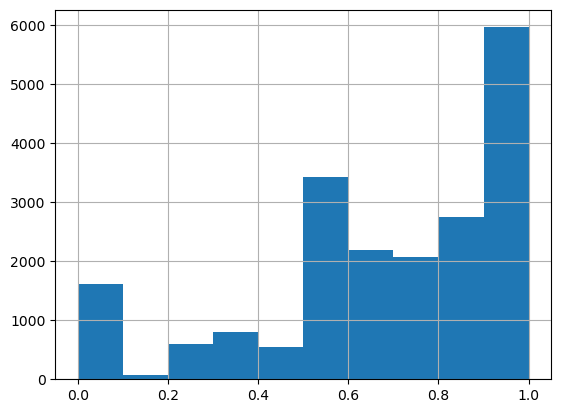

In [14]:
df['question_overlap'].hist()
plt.show()

In [15]:
df['question_overlap'].value_counts(bins = 10).sort_index()

(-0.002, 0.1]    1606
(0.1, 0.2]        246
(0.2, 0.3]        416
(0.3, 0.4]       1230
(0.4, 0.5]       2339
(0.5, 0.6]       1201
(0.6, 0.7]       2188
(0.7, 0.8]       3282
(0.8, 0.9]       1543
(0.9, 1.0]       5948
Name: count, dtype: int64

In [16]:
df.loc[df['question_overlap'] >= 0.8, 'clean_question'].size

8709

Распределение признака `question_overlap` смещено в сторону высоких значений (имеет левостороннюю асимметрию). Наибольшее число наблюдений сосредоточено в диапазоне `0.8-1.0`, что свидетельствует о высокой степени совпадения слов между текущими и предыдущими вопросами. При этом около `43,5%` всех вопросов имеют значение `question_overlap` не менее `0.8` (8709 из 19999 записей), что может указывать на наличие повторяющихся или тематически схожих вопросов. Вместе с тем наблюдается небольшое количество значений, близких к нулю, что свидетельствует о практически полном отсутствии пересечения слов между отдельными вопросами.

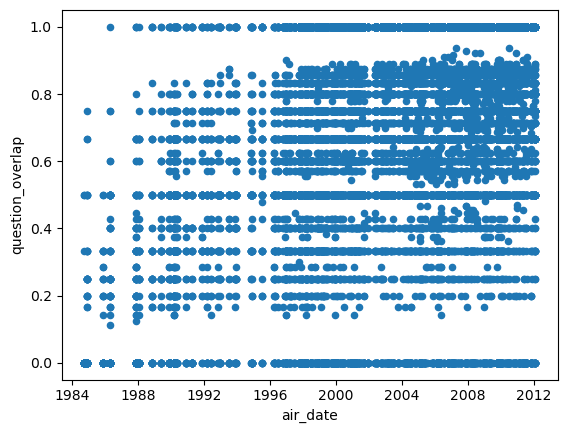

Коэффициент корреляции Пирсона между годом выпуска шоу и тематической схожестью вопросов: 0.36


In [17]:
df.plot(x = 'air_date', y = 'question_overlap', kind = 'scatter')
plt.show()
print(f"Коэффициент корреляции Пирсона между годом выпуска шоу и тематической схожестью вопросов: {round(df['year'].corr(df['question_overlap']), 2)}")

Полученное значение коэффициента корреляции (`0.36`) указывает на умеренную положительную связь между номером выпуска и степенью тематического пересечения вопросов. Это может свидетельствовать о тенденции к постепенному увеличению повторяемости тематик в более поздних выпусках.

Однако коэффициент корреляции отражает лишь общую тенденцию и не позволяет однозначно оценить, как изменялось распределение значений с течением времени. Для более детального анализа рассмотрим распределение коэффициента повторяемости тематик в вопросах викторины Jeopardy по временным интервалам, а также динамику его среднего значения и стандартного отклонения:

In [18]:
pivot_quest_overlap = df.pivot_table(index = 'year', values = 'question_overlap', aggfunc = ['mean', 'std'])

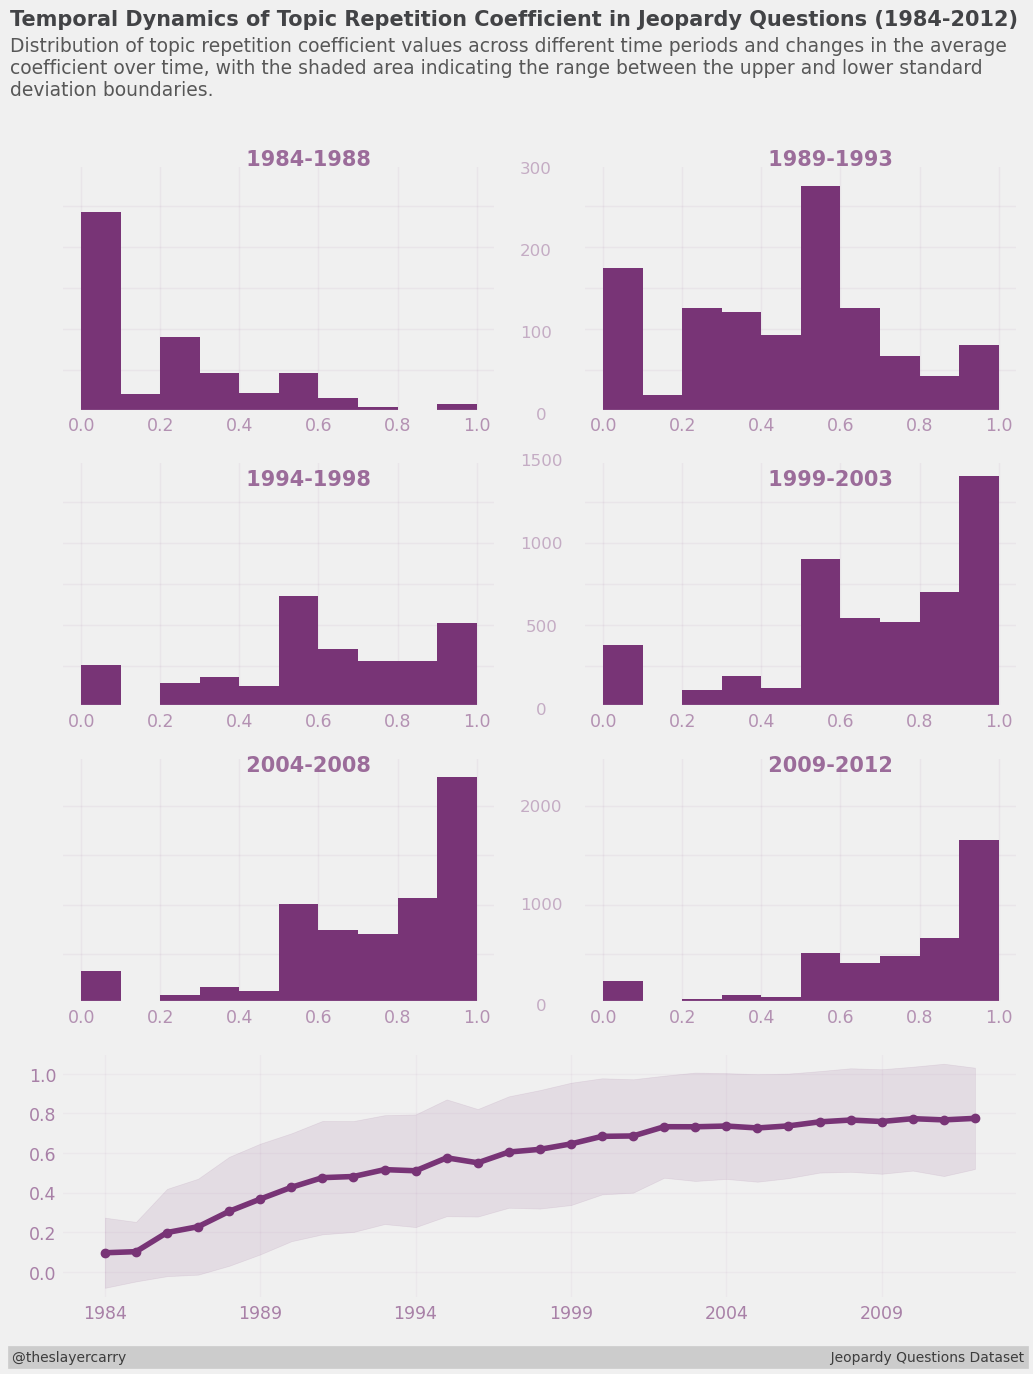

In [19]:
# Для данной визуализации мы будем использовать стиль `fivethirtyeight`
style.use('fivethirtyeight')
plt.figure(figsize = (11, 14), dpi = 100)

# Каждый ряд будет представлять данные за 9-летний период, начиная с 1984 года
ax1 = plt.subplot(4, 2, 1)
ax2 = plt.subplot(4, 2, 2)
ax3 = plt.subplot(4, 2, 3)
ax4 = plt.subplot(4, 2, 4)
ax5 = plt.subplot(4, 2, 5)
ax6 = plt.subplot(4, 2, 6)
axes = [ax1, ax2, ax3, ax4, ax5, ax6]

for ax, years in zip(axes, range(1984, 2010, 5)):
    ax.hist(df.loc[df['year'].between(years, years+4), 'question_overlap'], color = '#783476')
    
# Четвертый ряд представляет временную динамику среднего коэффициента повторяемости тематик с отображением верхней и нижней границ стандартного отклонения
ax7 = plt.subplot(4, 1, 4)
ax7.plot(pivot_quest_overlap.index, pivot_quest_overlap[('mean', 'question_overlap')], marker='o', color = '#783476')

mean = pivot_quest_overlap[('mean', 'question_overlap')]
std = pivot_quest_overlap[('std', 'question_overlap')]

ax7.fill_between(
    pivot_quest_overlap.index,
    mean - std,
    mean + std,
    alpha = 0.1,
    color = '#783476'
)

# Добавление текста и других структурных элементов
# Установка верхней границы частоты по оси Y для каждого ряда гистограмм
for i, lim_size in zip(range(0, 6, 2), [300, 1500, 2500]):
    for ax in axes[i:i+2]:
        ax.set_ylim(0, lim_size)
        ax.grid(alpha = 0.055, color = '#783476')
        ax.set_yticklabels([])
        
# Добавление подписей интервалов лет для каждой гистограммы, кроме последней  
for ax, years, y_coord in zip(axes, range(1984, 2005, 5), [300, 300, 1350, 1350, 2350]):
    ax.text(0.4, y_coord, s = f" {years}-{years+4} ", color = '#783476', weight = 'bold', size = 15, alpha = 0.7)
    
# Добавление подписи для последнего интервала лет   
ax6.text(0.4, 2350, s = f" {2009}-{2012} ", color = '#783476', weight = 'bold', size = 15, alpha = 0.7)

# Настройка подписей делений по оси X для каждой гистограммы
for ax in axes:
    for label in ax.get_xticklabels():
        label.set_alpha(0.5)
        label.set_color('#783476')
        label.set_fontsize(12.5)   # размер шрифта

# Настройка делений и оформления временного ряда динамики среднего коэффициента повторяемости тематик
ax7.set_xticks([1984, 1989, 1994, 1999, 2004, 2009])
ax7.grid(alpha = 0.04, color = '#783476')        
ax7.tick_params(
    axis='both',
    colors='#a880a7',
    labelsize=12.5,
)

# Рисуем отметки на оси Y для каждого ряда:
rows_ticks_coords = [[100, 200, 300],
                     [1000, 1500],
                     [1000, 2000]]

for row_index, ticks in zip(range(0, 6, 2), rows_ticks_coords):
    for tick in ticks:
        axes[row_index].text(1.11, tick - (row_index * 10 + 10), s = tick, color = '#783476',  size = 12, alpha = 0.36)
        
# Отдельно рисуем нули, чтобы они были посередине
for row_index in range(0, 6, 2):
        axes[row_index].text(1.15, 0 - (row_index * 15 + 10), s = '0', color = '#783476',  size = 12, alpha = 0.36)
    
# Отдельно рисуем отметку 500 для второго ряда, чтобы она была посередине
ax3.text(1.125, 500 - (2 * 15 + 10), s = '500', color = '#783476',  size = 12, alpha = 0.36)

# Заголовок
ax1.text(x = -0.18, y = 470, s = 'Temporal Dynamics of Topic Repetition Coefficient in Jeopardy Questions (1984-2012)', size = 15, weight = 'bold', color = '#242528', alpha = 0.85)

# Подзаголовок
ax1.text(x = -0.18, y = 385, s = '''Distribution of topic repetition coefficient values across different time periods and changes in the average 
coefficient over time, with the shaded area indicating the range between the upper and lower standard
deviation boundaries.''', size = 13.5, color = "#575757")

#Подпись создателя
ax7.text(1981, -0.45, s = "@theslayercarry" + 161*" " + "Jeopardy Questions Dataset", backgroundcolor = '#cccccc', size = 10, alpha = 0.7)

plt.show()
style.use('default')

Во всех временных интервалах распределение коэффициента повторяемости тематик остается преимущественно асимметричным. Однако характер этой асимметрии со временем существенно изменяется. Если в ранних выпусках большинство вопросов характеризуется низкими значениями коэффициента, а распределение имеет длинный правый хвост, то в последующие годы основная масса наблюдений постепенно смещается в область высоких значений коэффициента. Это свидетельствует о заметном увеличении доли вопросов с высокой степенью тематической повторяемости.

---

Рассмотрим, как часто определённые слова встречаются в двух категориях вопросов:

- с высокой стоимостью вознаграждения (более $800)

- с низкой стоимостью вознаграждения ($800 или меньше)

In [20]:
greater_800_mask = (df['value_usd'] > 800).map({True: 'High value', False: 'Low value'})
df['value_usd_category'] = greater_800_mask
df['value_usd_category'].value_counts()

value_usd_category
Low value     14265
High value     5734
Name: count, dtype: int64

In [21]:
word_category_dict = {} #Словарь, в котором ключ - уникальное слово из terms_used, 
                        #а значение - кортеж с частотой встречаемости данного слова среди вопросов с низкой и высокой стоимостью

for term in terms_used: # Для каждого слова из terms_used
    #Создаём булевую маску для фильтрации строк серии clean_question, которые содержат в себе итерируемое слово
    contain_term_mask = df['clean_question'].str.contains(term, na = False, regex=False) 
    #Среди данных строк выбираем столбец value_usd_category
    rows_include_term = df.loc[contain_term_mask, 'value_usd_category']
    #Используем метод value_counts() с get() для подсчёта частотного распределения категорий вопросов
    usd_categories = rows_include_term.value_counts()
    high_count = usd_categories.get('High value', 0)
    low_count = usd_categories.get('Low value', 0)
    #Заполняем словарь
    word_category_dict[term] = (high_count, low_count)

В результате мы получаем словарь `word_category_dict`, в котором для каждого слова указана частота его встречаемости среди вопросов с высоким и низким вознаграждением за правильный ответ. Преобразуем данный словарь в датафрейм для последующей дополнительной фильтрации:

In [22]:
unique_words_df = pd.DataFrame.from_dict(word_category_dict, orient='index', columns=['high_count', 'low_count'])
unique_words_df = unique_words_df.reset_index(names = 'word')

unique_words_df['total'] = unique_words_df['high_count'] + unique_words_df['low_count'] # Общее число вопросов, содержащих данное слово
unique_words_df.info()
unique_words_df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25183 entries, 0 to 25182
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   word        25183 non-null  object
 1   high_count  25183 non-null  int64 
 2   low_count   25183 non-null  int64 
 3   total       25183 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 787.1+ KB


,word,high_count,low_count,total
0,scathing,0,1,1
1,inland,12,18,30
2,methot,0,1,1
3,semiconducting,1,0,1
4,nonhuman,0,1,1


In [23]:
pattern = r"[<>/_=]"
erroneous_data_mask = unique_words_df['word'].str.contains(pattern, na = False)
unique_words_df[erroneous_data_mask].sort_values('total', ascending = False)

,word,high_count,low_count,total
21339,target=_blank>,345,407,752
2796,here</a>,111,180,291
11923,target=_blank>here</a>,98,148,246
572,this</a>,73,95,168
1433,target=_blank>this,71,76,147
...,...,...,...,...
168,target=_blank>),1,0,1
156,href=http//wwwj-archivecom/media/2008-03-10_j_...,0,1,1
152,href=http//wwwj-archivecom/media/2007-11-15_j_...,1,0,1
148,href=http//wwwj-archivecom/media/2012-01-18_dj...,1,0,1


При анализе списка уникальных слов было выявлено, что часть из них представляет собой фрагменты HTML-разметки, URL-адреса, атрибуты HTML-тегов и другие технические элементы, сохранившиеся вследствие неполной очистки исходных данных. Поскольку такие элементы не несут смысловой нагрузки и не характеризуют содержание вопросов, они были исключены из дальнейшего анализа.

In [24]:
unique_words_df = unique_words_df[~erroneous_data_mask]
unique_words_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23294 entries, 0 to 25182
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   word        23294 non-null  object
 1   high_count  23294 non-null  int64 
 2   low_count   23294 non-null  int64 
 3   total       23294 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 909.9+ KB


Рассмотрим слова, которые встречаются более 30 раз среди вопросов с высоким вознаграждением:

In [25]:
unique_words_df[unique_words_df['high_count'] > 30]

,word,high_count,low_count,total
401,monitor,37,18,55
545,family,48,111,159
841,feature,35,126,161
1141,include,77,177,254
1210,country,158,420,578
...,...,...,...,...
24171,between,51,92,143
24298,secret,39,67,106
24604,leader,42,82,124
24882,follow,46,95,141


Таким образом, среди вопросов с вознаграждением свыше 800 долларов было выявлено 94 уникальных слова, каждое из которых встречается более 30 раз.

Для выбранных слов рассчитаем хи-квадрат тест, чтобы проверить, существует ли статистически значимая разница в их использовании в вопросах с высоким и низким вознаграждением:

In [26]:
category_usd_freq = df['value_usd_category'].value_counts()

high_value_count = category_usd_freq['High value']
low_value_count = category_usd_freq['Low value']

total_docs = high_value_count + low_value_count

chi_stat = []
chi_pvalue = []

for index, row in unique_words_df.iterrows():
    total_prop = row['total'] / total_docs

    expected_high = total_prop * high_value_count
    expected_low = total_prop * low_value_count

    observed = np.array([row['high_count'], row['low_count']])
    expected = np.array([expected_high, expected_low])

    result = chisquare(observed, expected)

    chi_stat.append(result.statistic)
    chi_pvalue.append(result.pvalue)

unique_words_df['chi_stat'] = chi_stat
unique_words_df['chi_pvalue'] = chi_pvalue
unique_words_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23294 entries, 0 to 25182
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   word        23294 non-null  object 
 1   high_count  23294 non-null  int64  
 2   low_count   23294 non-null  int64  
 3   total       23294 non-null  int64  
 4   chi_stat    23294 non-null  float64
 5   chi_pvalue  23294 non-null  float64
dtypes: float64(2), int64(3), object(1)
memory usage: 1.2+ MB


Определим наиболее значимые слова на основе значений p-value:

In [27]:
significant_words = unique_words_df[unique_words_df['chi_pvalue'] < 0.05].sort_values('high_count', ascending = False)
significant_words.head(20)

,word,high_count,low_count,total,chi_stat,chi_pvalue
10697,archive,422,529,951,114.664202,9.321863e-27
9880,target,352,410,762,114.405970,1.061839e-26
18584,called,169,346,515,4.324689,3.756328e-02
8219,french,119,143,262,35.936498,2.038541e-09
1646,letter,94,175,269,5.175626,2.290592e-02
17897,report,78,110,188,15.103605,1.017688e-04
22190,reports,65,81,146,17.932876,2.288339e-05
22812,meaning,60,102,162,5.543661,1.854774e-02
15476,africa,60,67,127,21.420967,3.687169e-06
17377,direct,55,85,140,7.712519,5.483916e-03


Для более наглядного представления результатов анализа построим столбчатую диаграмму, отображающую частотное распределение слов, наиболее характерных для вопросов с высокой стоимостью вознаграждения:

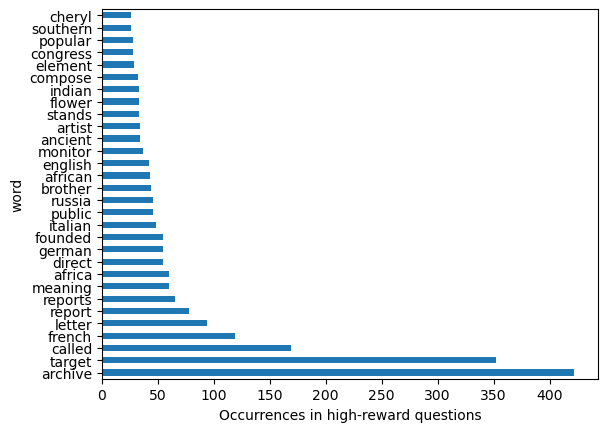

In [28]:
significant_words.head(30).plot(x = 'word', y = 'high_count', kind = 'barh', xlabel = 'Occurrences in high-reward questions', legend = False)
plt.show()

По результатам хи-квадрат теста были выявлены слова, частота появления которых статистически значимо различается между вопросами с высоким и низким вознаграждением. Среди них присутствуют такие содержательные слова, как `english`, `french`, `artist`, `ancient`, `russia`, `africa`.

Среди содержательных статистически значимых слов заметно преобладают термины, относящиеся к следующим тематическим областям:

- География и страны: africa, african, russia, french, german, english, italian, indian.

- История: ancient, founded.

- Культура и искусство: artist, compose.

- Общество и политика: public, report, reports.

Полученные результаты позволяют предположить, что вопросы с высоким вознаграждением чаще содержат термины, связанные с географией, историей, культурой и общественно-политической тематикой.

---

In [29]:
df.iloc[[0, -1]] #Выведем первую и последнюю запись датасета

,show_number,air_date,round,category,value_usd,question,answer,clean_question,clean_answer,year,answer_in_question,question_overlap,value_usd_category
0,10,1984-09-21,Final Jeopardy!,U.S. PRESIDENTS,0,"Adventurous 26th president, he was 1st to ride...",Theodore Roosevelt,adventurous 26th president he was 1st to ride ...,theodore roosevelt,1984,0.0,0.0,Low value
19998,6294,2012-01-19,Jeopardy!,THAT'S BUSINESS,400,In 1997 Tyco International moved to this U.K. ...,Bermuda,in 1997 tyco international moved to this uk te...,bermuda,2012,0.0,1.0,Low value


Поскольку данные отсортированы по дате проведения шоу (с 21 сентября 1984 года по 19 января 2012 года), их можно рассматривать как временной ряд, позволяющий анализировать изменение стоимости вопросов по мере развития шоу:

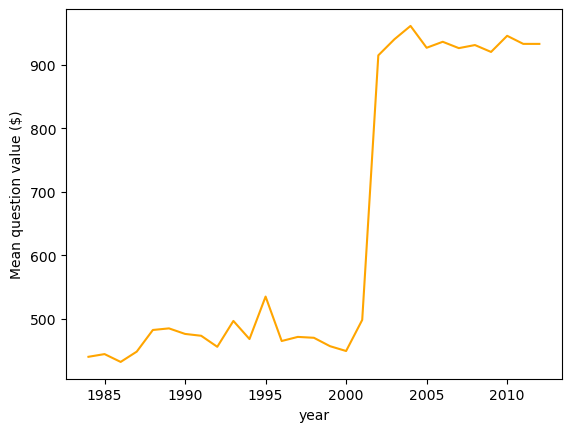

In [30]:
pivot_usd = df.pivot_table(index = 'year', values = 'value_usd', aggfunc = ['mean', 'max'])
pivot_usd.plot(kind = 'line', y = ('mean','value_usd'), legend = False, color = 'orange', ylabel = 'Mean question value ($)')
plt.show()

По графику видно, что средняя стоимость вопросов существенно увеличивается после 2001 года. Однако данный интервал является достаточно широким (2001-2012), поэтому дополнительно рассмотрим график максимальной стоимости вопроса по годам выпуска. Это позволит определить, в какие годы встречались наиболее дорогие вопросы, а также как изменялся верхний предел стоимости со временем:

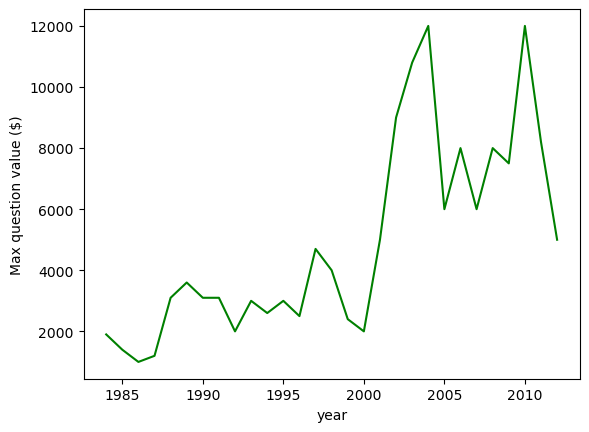

In [31]:
pivot_usd.plot(kind = 'line', y = ('max','value_usd'), legend = False, color = 'green', ylabel = 'Max question value ($)')
plt.show()

Для детального исследования рассмотрим два наиболее продолжительных периода в истории телешоу Jeopardy! в рамках доступного набора данных: до и после 2000 года. Как было отмечено ранее, после 2000 года наблюдается выраженный рост номиналов вопросов: увеличиваются как средние значения, так и верхние границы распределения. В отдельные годы максимальный номинал достигает `9000–12000$` (например, 2002, 2003, 2004 и 2010 годах).

В Jeopardy! более сложные и уникальные вопросы традиционно имеют более высокий номинал. Для учёта этого эффекта в данных был введён признак `question_overlap`, отражающий степень тематической и лексической схожести текущего вопроса с предыдущими. Анализ этого признака позволяет определить, была ли в годы с максимальными номиналами тенденция к повторению тем и формулировок либо, напротив, высокие номиналы обусловливались новизной вопросов.

Выделены следующие годы с пиковыми значениями номиналов:
- до 2000 года: 1997 год ($4700),

- после 2000 года: 2002, 2003, 2004, 2008 и 2010 годы.

На основе этих наблюдений целесообразно построить визуализацию, отражающую взаимосвязь между номиналом вопроса, степенью тематического пересечения и раундом, к которому он относится. 

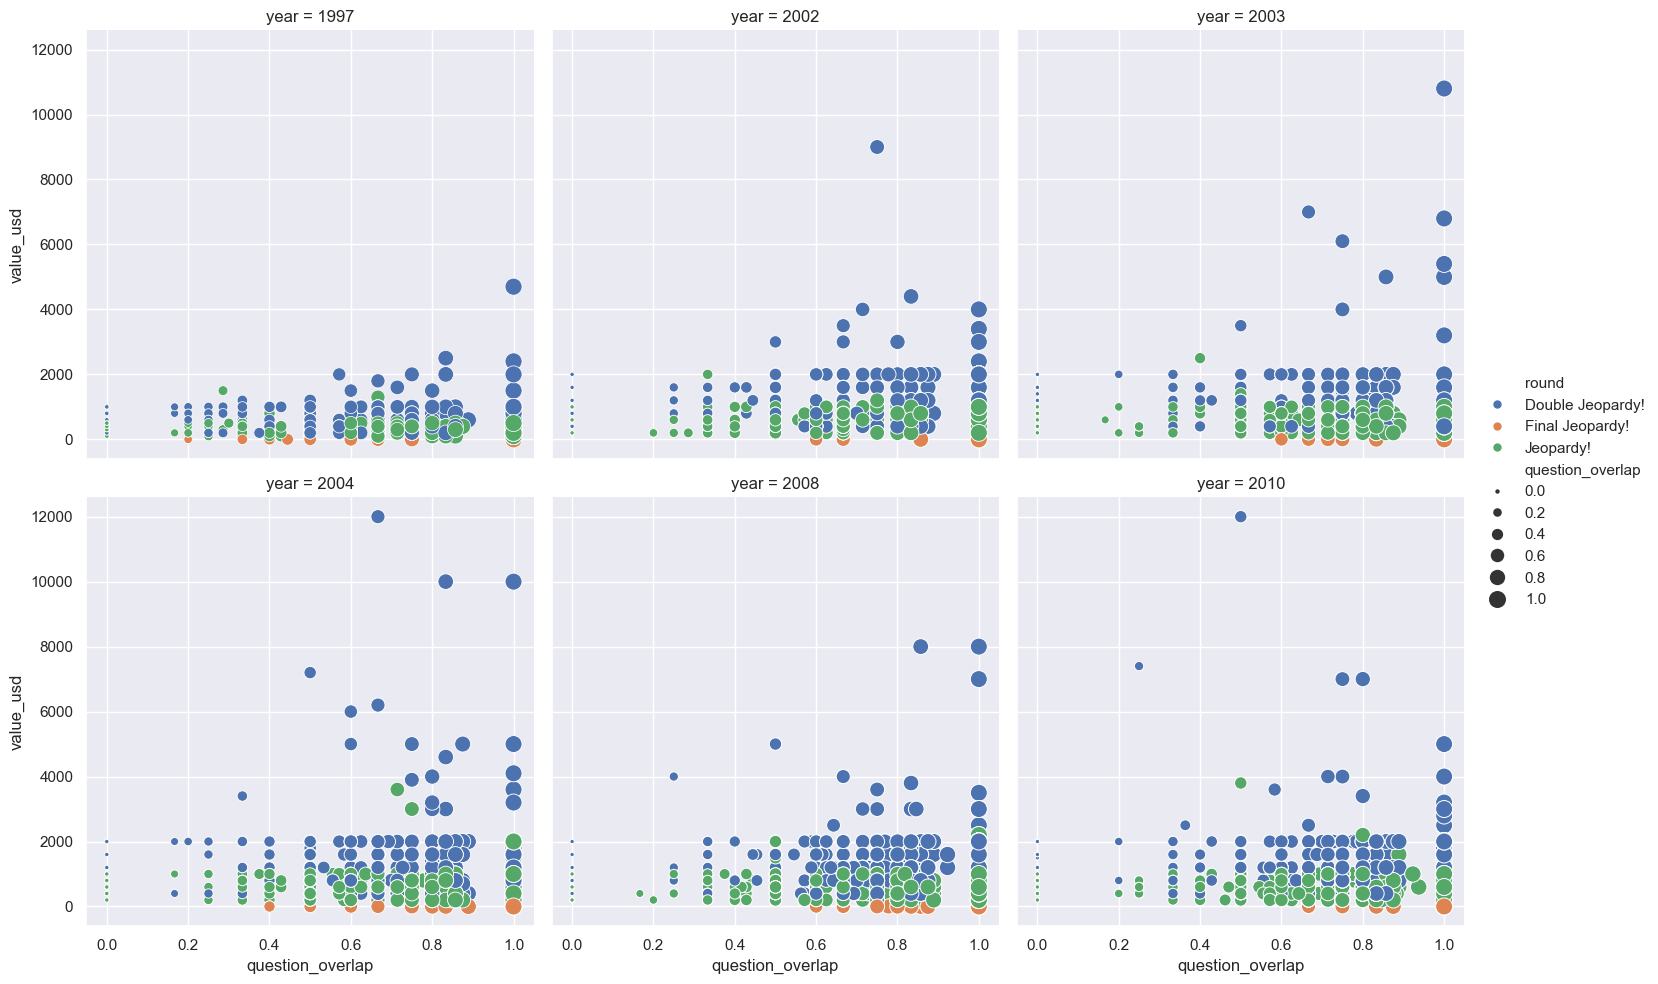

In [32]:
sns.set_theme()
sns.relplot(data = df[df['year'].isin([1997, 2002, 2003, 2004, 2008, 2010])], x = 'question_overlap',
                       y = 'value_usd',
                       hue = 'round',
                       size = 'question_overlap',
                       sizes = (10, 150),
                       col = 'year',
                       col_wrap = 3)
                
plt.show()

По реляционному графику видно, что среди выбранных годов в выпусках преобладает раунд `Double Jeopardy!`. Размер точек отражает значения признака `question_overlap`: в вопросах с максимальной стоимостью темы или отдельные слова уже встречались в предыдущих по времени выпусках. В сочетании с результатами хи-квадрат теста, а также анализом слов, для которых были выявлены статистически значимые различия, это позволяет предположить наличие устойчивых тематических направлений в наиболее «дорогих» вопросах.

Финальный раунд (`Final Jeopardy!`) на графиках отмечен оранжевым цветом и расположен в нижней части распределения, поскольку для него стоимость вопросов была установлена равной нулю. Это связано с отсутствием значений номинала в исходных данных исключительно для данного раунда, что указывает на особенность представления данных, а не на их реальное отсутствие. Вероятно, это обусловлено форматом финального раунда, в котором участники делают ставку на основе текущего накопленного выигрыша.